# 02 · User Behaviour

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**

This notebook profiles *who* the user base is: geography, platform, how
they were acquired, age, A/B test assignment, and device type. Understanding
composition is the prerequisite for every segmented analysis in the rest of
this suite (retention by platform, funnel by channel, and so on) — you
can't interpret "iOS converts 6pp better than Web" without first knowing
whether iOS is 10% or 50% of the user base.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


In [2]:
COUNTRY_COLOR = build_color_map(users["country"])
# Explicit (not alphabetical) mapping for platform: readers carry real-world
# colour associations for iOS/Android, so we honour those rather than the
# generic sorted-order assignment used for channels/countries below.
PLATFORM_COLOR = {"iOS": PALETTE[0], "Android": PALETTE[1], "Web": PALETTE[5]}
CHANNEL_COLOR = build_color_map(users["acquisition_channel"])
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+", "Unspecified"]
AGE_COLOR = dict(zip(AGE_ORDER, PALETTE))


def categorical_bar(counts: pd.Series, color_map: dict, title: str, xlabel: str,
                     ylabel: str = "Number of Users", rotate: int = 0, fmt: str = "{:,.0f}"):
    """Vertical bar chart for a categorical value_counts() series, using a fixed colour map."""
    fig, ax = plt.subplots(figsize=(8.5, 5))
    colors = [color_map[c] for c in counts.index]
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors)
    annotate_bars(ax, bars, fmt=fmt)
    style_axis(ax, title, xlabel, ylabel)
    if rotate:
        plt.xticks(rotation=rotate, ha="right")
    ax.set_ylim(0, counts.values.max() * 1.15)
    plt.tight_layout()
    return fig, ax

## Section 1 — Countries

**Business Question.** Which markets is the user base concentrated in, and
does that match where the business has actually invested in launch/marketing?

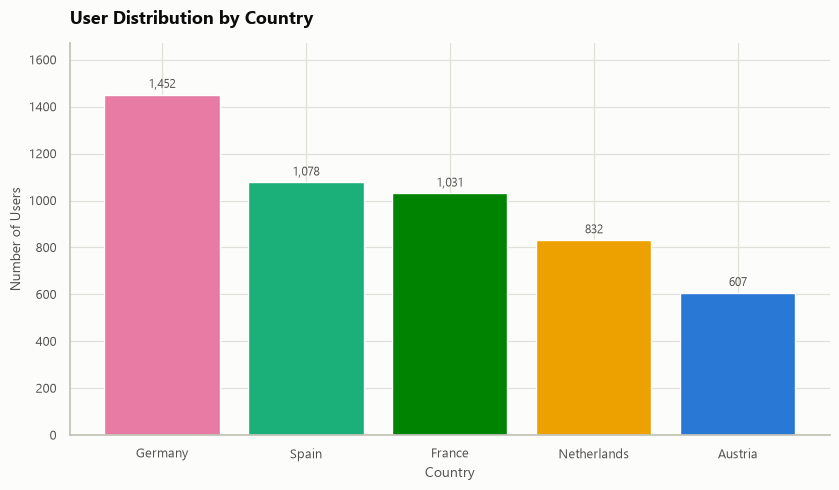

In [3]:
country_counts = users["country"].value_counts()
fig, ax = categorical_bar(country_counts, COUNTRY_COLOR, "User Distribution by Country", "Country")
save_fig(fig, "07_users_by_country", IMAGES_DIR)
plt.show()

**Business Insight.** Germany (~29%) and Spain (~22%) together account for
over half the user base — this is a two-market-led product today, not yet
a balanced pan-European one. Austria is the smallest market at ~12%.

**Recommendation.** Treat Germany and Spain as the primary markets for any
feature rollout sequencing or A/B test power calculation (they'll reach
significance fastest); evaluate whether Austria's smaller base reflects a
genuine market-size ceiling or under-investment worth testing further.

## Section 2 — Cities

**Business Question.** Within each country, is usage concentrated in a
single flagship city or spread across multiple metro areas?

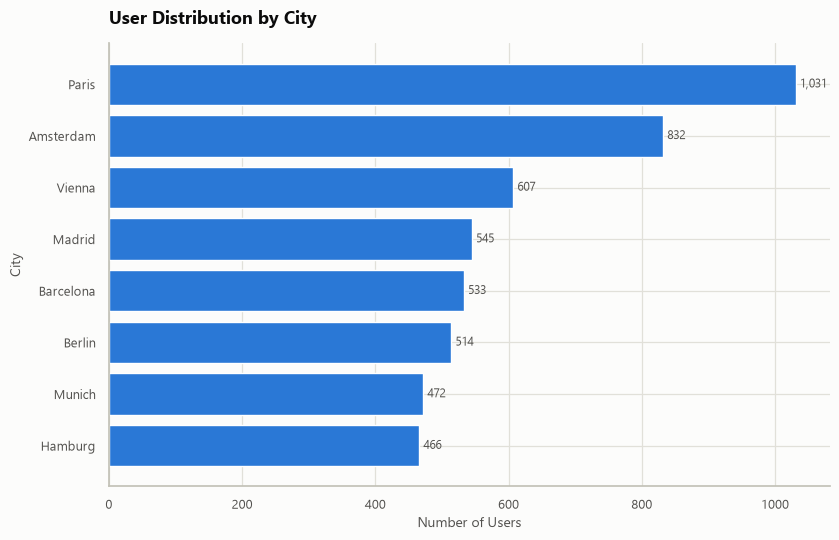

In [4]:
city_counts = users["city"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.barh(city_counts.index, city_counts.values, color=PALETTE[0])
annotate_bars(ax, bars, horizontal=True)
style_axis(ax, "User Distribution by City", "Number of Users", "City", grid_axis="x")
plt.tight_layout()
save_fig(fig, "08_users_by_city", IMAGES_DIR)
plt.show()

**Business Insight.** Germany's user base is split across three cities
(Berlin, Hamburg, Munich), while Austria, the Netherlands, and France each
rely on a single flagship city (Vienna, Amsterdam, Paris) for effectively
all of their volume. Multi-city presence is a structural reason Germany
leads on total users, independent of any per-city performance difference.

**Recommendation.** When benchmarking "market performance," compare
per-city metrics, not per-country totals — a single-city market being
smaller in aggregate doesn't mean it under-performs on a like-for-like
basis.

## Section 3 — Platforms

**Business Question.** How is the user base split across iOS, Android, and
Web — and does that split match where product investment is going?

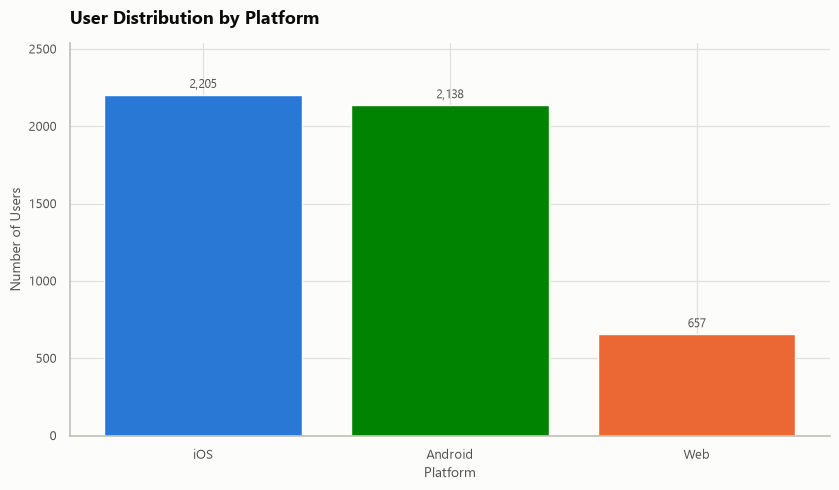

In [5]:
platform_counts = users["platform"].value_counts()
fig, ax = categorical_bar(platform_counts, PLATFORM_COLOR, "User Distribution by Platform", "Platform")
save_fig(fig, "09_users_by_platform", IMAGES_DIR)
plt.show()

**Business Insight.** iOS (44%) and Android (43%) are almost perfectly
balanced, with Web a distant third (13%) — expected for a mobility app,
where booking a ride from a phone in-hand is the natural use case. Web is
likely serving a different job (desktop research, business travel
expensing) rather than being a shrinking mobile channel.

**Recommendation.** Do not treat Web as a lower priority than its user
share suggests without first checking its use case — Section 6/8 revenue
findings should inform whether Web is worth a dedicated product investment
or is inherently a secondary channel.

## Section 4 — Acquisition Channels

**Business Question.** Where are users coming from, and does the channel
mix reflect an efficient acquisition strategy or an over-reliance on paid
spend?

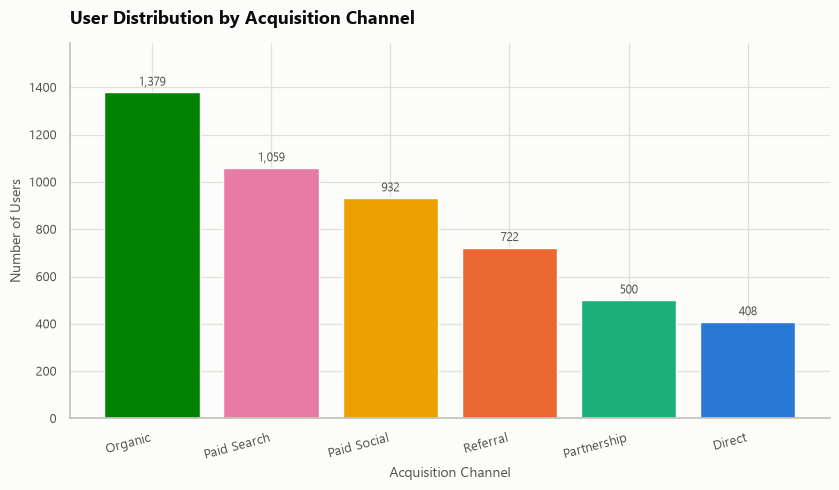

In [6]:
channel_counts = users["acquisition_channel"].value_counts()
fig, ax = categorical_bar(channel_counts, CHANNEL_COLOR, "User Distribution by Acquisition Channel",
                            "Acquisition Channel", rotate=15)
save_fig(fig, "10_users_by_channel", IMAGES_DIR)
plt.show()

**Stacked view: acquisition channel composition by platform** — does the
channel mix differ by platform (e.g. is Paid Social disproportionately
driving Web signups)?

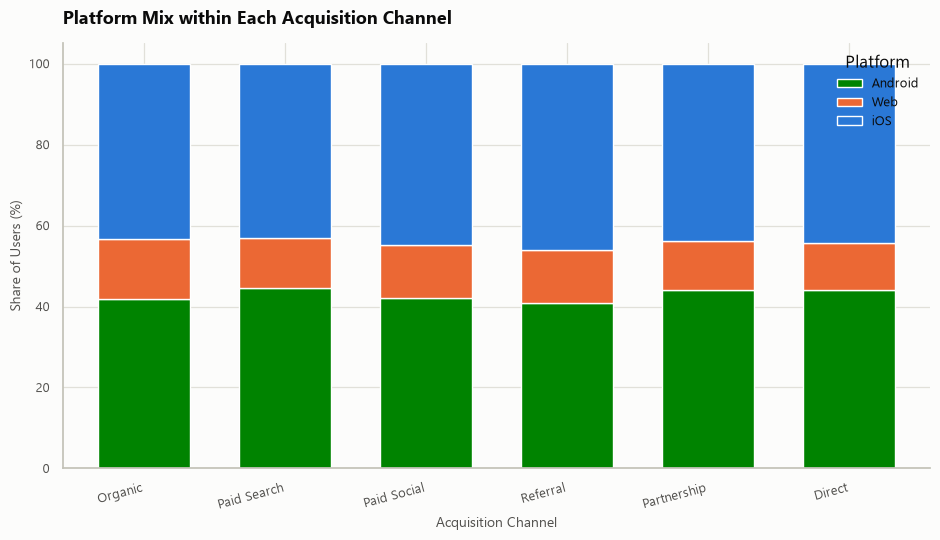

In [7]:
channel_platform = pd.crosstab(users["acquisition_channel"], users["platform"], normalize="index") * 100
channel_platform = channel_platform.loc[channel_counts.index]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
channel_platform.plot(kind="bar", stacked=True, color=[PLATFORM_COLOR[p] for p in channel_platform.columns], ax=ax, width=0.65)
style_axis(ax, "Platform Mix within Each Acquisition Channel", "Acquisition Channel", "Share of Users (%)")
ax.legend(title="Platform", frameon=False, fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "11_channel_platform_stacked", IMAGES_DIR)
plt.show()

**Business Insight.** Organic (28%) is the single largest channel, ahead of
Paid Search (21%) and Paid Social (19%) combined spend-driven channels;
Referral, despite being only 14% of volume, will prove in later notebooks
to be the highest-quality channel by conversion and revenue per user. The
platform mix is broadly consistent across channels — no channel is
skewing unusually toward Web, so platform-specific channel targeting isn't
an obvious lever here.

**Recommendation.** Prioritise scaling Referral (formal incentive program)
over increasing Paid Social spend — see the full quality comparison in
Notebook 04 (funnel) and Notebook 06 (executive summary).

## Section 5 — Age Groups

**Business Question.** What's the age profile of the user base, and does
it match the target demographic for a mobility product?

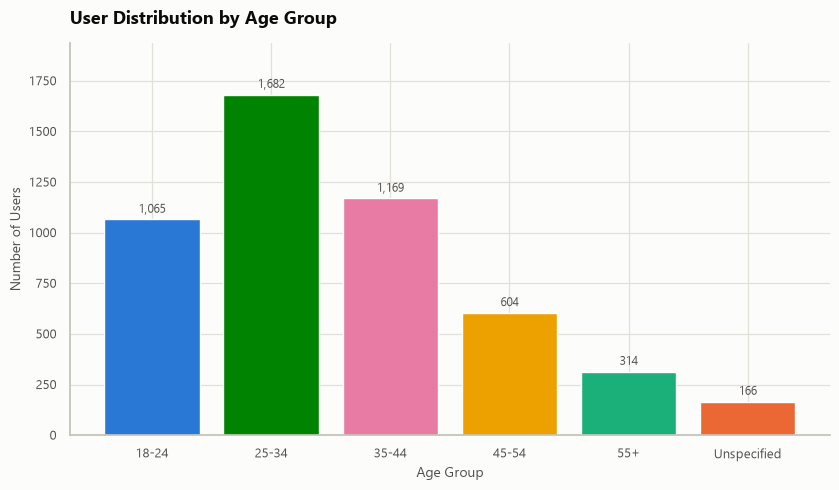

In [8]:
age_counts = users["age_group"].fillna("Unspecified").value_counts().reindex(AGE_ORDER)
fig, ax = categorical_bar(age_counts, AGE_COLOR, "User Distribution by Age Group", "Age Group")
save_fig(fig, "12_users_by_age_group", IMAGES_DIR)
plt.show()

**Business Insight.** The distribution skews young: 18-44 year-olds make up
~79% of the base, with 25-34 the single largest band (~34%). This matches
the expected demographic for an urban mobility app and suggests marketing
creative and partnership choices (e.g. student/young-professional
partnerships) are likely well-targeted.

**Recommendation.** The 45+ segment (~18%) is comparatively under-represented
— worth a lightweight test of messaging tailored to older users before
concluding the product simply doesn't appeal to that segment.

## Section 6 — Experiment Groups

**Business Question.** Is the `simplified_booking_flow` A/B test properly
randomised — i.e. is the control/treatment split actually balanced?
An imbalanced split can bias experiment results before any statistical
test is even run.

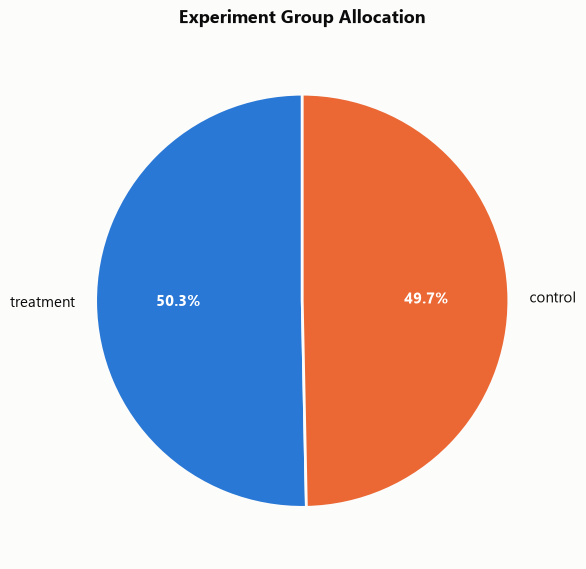

experiment_group
treatment    2516
control      2484
Name: count, dtype: int64

In [9]:
exp_group_counts = experiments["experiment_group"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = [COLOR_CONTROL, COLOR_TREATMENT]
wedges, _, autotexts = ax.pie(
    exp_group_counts.values, labels=exp_group_counts.index, colors=colors,
    autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": SURFACE, "linewidth": 2},
    textprops={"color": INK, "fontsize": 11},
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
ax.set_title("Experiment Group Allocation", fontsize=13, fontweight="bold", color=INK, pad=14)
plt.tight_layout()
save_fig(fig, "13_experiment_group_split", IMAGES_DIR)
plt.show()

exp_group_counts

**Business Insight.** The split is close to 50/50 (2,484 control / 2,516
treatment) — randomisation is balanced, so any conversion or revenue
difference measured in Notebook 05 can be attributed to the treatment
itself rather than a sampling artefact. (A pie chart is used here
deliberately — with exactly two categories summing to 100%, it communicates
"the whole is split roughly in half" faster than a bar chart would.)

**Recommendation.** No action needed on randomisation; proceed to the full
experiment readout in Notebook 05.

## Section 7 — Device Types

**Business Question.** Does the device used *at signup* (`first_device_type`)
match the user's primary `platform`, or is there meaningful cross-device
behaviour (e.g. signing up via a mobile browser before installing the app)?

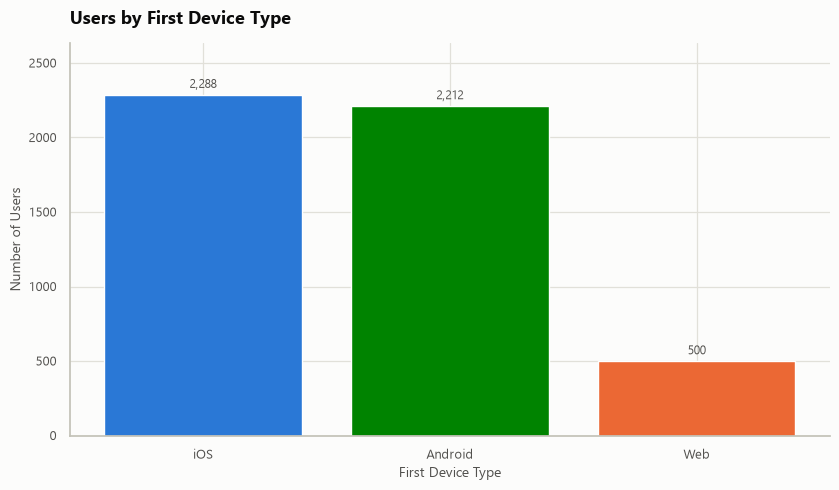

Share of users whose first_device_type differs from their platform: 3.1%


In [10]:
device_counts = users["first_device_type"].value_counts()
fig, ax = categorical_bar(device_counts, PLATFORM_COLOR, "Users by First Device Type", "First Device Type")
save_fig(fig, "14_users_by_first_device", IMAGES_DIR)
plt.show()

mismatch_rate = (users["first_device_type"] != users["platform"]).mean() * 100
print(f"Share of users whose first_device_type differs from their platform: {mismatch_rate:.1f}%")

**Business Insight.** A small minority of users have a `first_device_type`
that differs from their primary `platform` — consistent with a
mobile-browser signup that later converts to app usage. This is a small
effect but confirms the signup funnel isn't perfectly app-native for 100%
of users.

**Recommendation.** No immediate action; if this share grows over time it
would be worth instrumenting a specific "web-to-app" conversion funnel.

## Section 8 — Country × Platform Heatmap

**Business Question.** Is the platform mix (iOS/Android/Web) consistent
across every country, or does any market show an unusual platform skew
worth investigating?

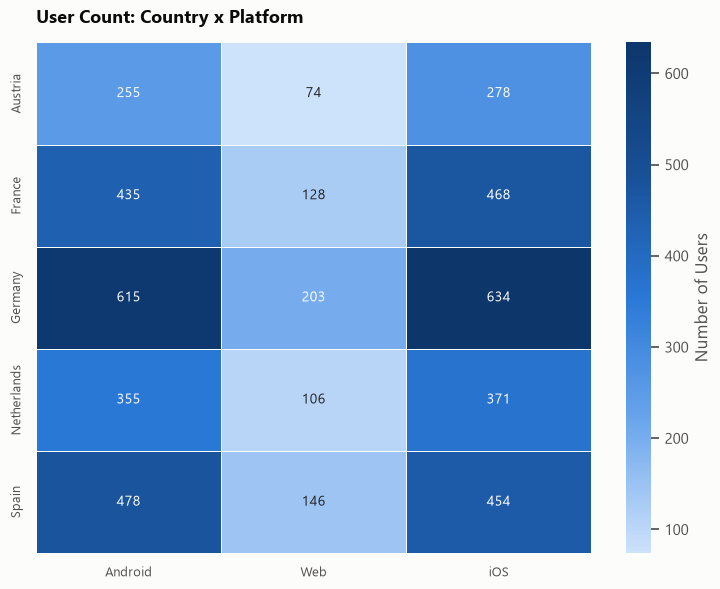

In [11]:
country_platform = pd.crosstab(users["country"], users["platform"])

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(country_platform, annot=True, fmt=",d", cmap=BLUE_SEQUENTIAL, linewidths=0.6,
             linecolor=SURFACE, cbar_kws={"label": "Number of Users"}, ax=ax)
style_axis(ax, "User Count: Country x Platform", grid_axis="")
plt.tight_layout()
save_fig(fig, "15_country_platform_heatmap", IMAGES_DIR)
plt.show()

**Business Insight.** The iOS/Android/Web ratio is consistent across all
five countries — no market shows an unusual platform skew. This means
platform-level findings elsewhere in this suite (e.g. "Web underperforms on
conversion") generalise across markets rather than being driven by one
country's platform mix.

**Recommendation.** None required; this confirms platform comparisons don't
need to be re-cut by country to be valid.

## Top Behavioural Observations

- The user base is **concentrated in two markets** (Germany, Spain) and
  **two platforms** (iOS, Android) — Web and the smaller markets are
  minority segments worth watching but not yet primary.
- **Referral is a small-volume, high-signal channel** — its quality (shown
  in later notebooks) makes it disproportionately valuable relative to its
  14% share of signups.
- **Randomisation for the `simplified_booking_flow` experiment is balanced**,
  giving confidence in the Notebook 05 readout.
- **Platform mix is stable across every market** — findings about platform
  performance generalise, rather than being an artefact of one country's
  user base.